In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Dataset de Kaggle
https://www.kaggle.com/datasets/abhishekmishra08/loan-approval-datasets

In [27]:
# Dataset
file_path = "loan_data.csv"
df = pd.read_csv(file_path)

In [28]:
# Primer acercamiento a los datos
df_info = df.info()
df_head = df.head()
df_description = df.describe(include='all')

df_head, df_description

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Text               24000 non-null  object 
 1   Income             24000 non-null  int64  
 2   Credit_Score       24000 non-null  int64  
 3   Loan_Amount        24000 non-null  int64  
 4   DTI_Ratio          24000 non-null  float64
 5   Employment_Status  24000 non-null  object 
 6   Approval           24000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 1.3+ MB


(                                                Text  Income  Credit_Score  \
 0  I need a loan to pay for an international vaca...   26556           581   
 1  I want to make home improvements like installi...  197392           389   
 2  I need a loan for home renovation, including a...   44561           523   
 3  I need funds to buy new furniture and applianc...  190363           729   
 4           I need a loan to start a small business.   61853           732   
 
    Loan_Amount  DTI_Ratio Employment_Status  Approval  
 0         8314      79.26          employed  Rejected  
 1       111604      22.14          employed  Rejected  
 2        34118      45.44          employed  Rejected  
 3       118757      10.22        unemployed  Rejected  
 4        19210      44.13          employed  Approved  ,
                                                      Text         Income  \
 count                                               24000   24000.000000   
 unique                    

In [29]:
# Configuración de estilo
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Gráficos de distribución para variables numéricas
def plot_histograms(df, cols):
    for col in cols:
        plt.figure()
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribución de {col}')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.tight_layout()

# Boxplots por variable objetivo
def plot_boxplots(df, cols, target):
    for col in cols:
        plt.figure()
        sns.boxplot(x=target, y=col, data=df)
        plt.title(f'{col} por {target}')
        plt.tight_layout()

# Gráfico de barras para Employment_Status vs Approval
def plot_employment_vs_approval(df):
    plt.figure()
    sns.countplot(x='Employment_Status', hue='Approval', data=df)
    plt.title('Estado de empleo vs Aprobación')
    plt.tight_layout()

# Heatmap de correlación
def plot_correlation_heatmap(df):
    plt.figure(figsize=(8,6))
    corr = df.select_dtypes(include=['float64', 'int64']).corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlación')
    plt.tight_layout()

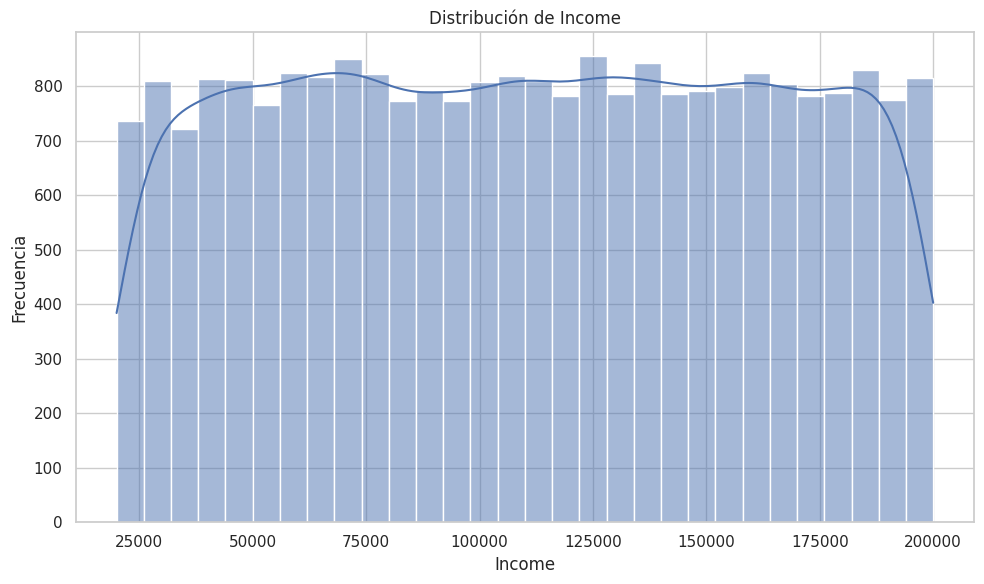

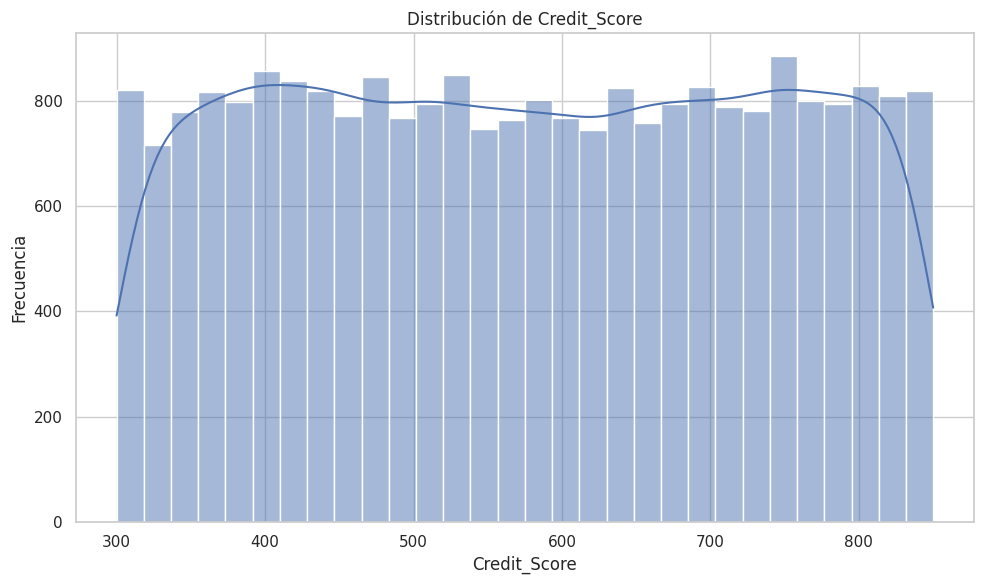

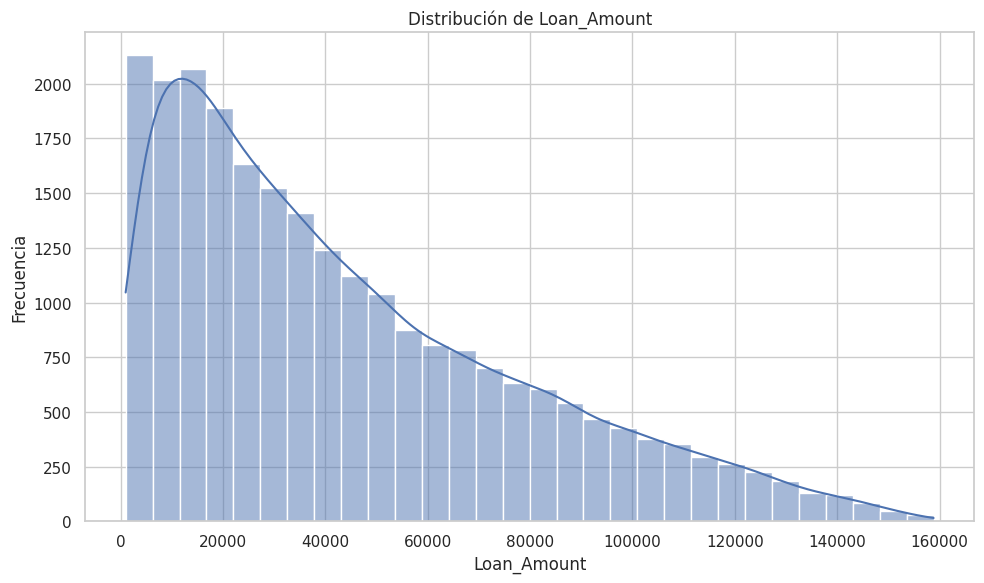

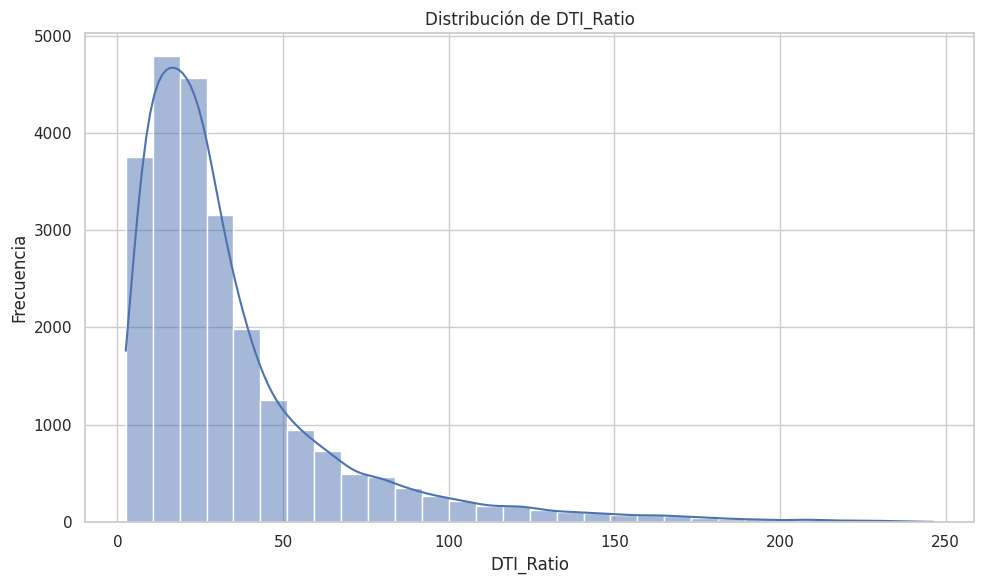

In [30]:
# Ejecutar todos los gráficos
numeric_cols = ['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio']
plot_histograms(df, numeric_cols)

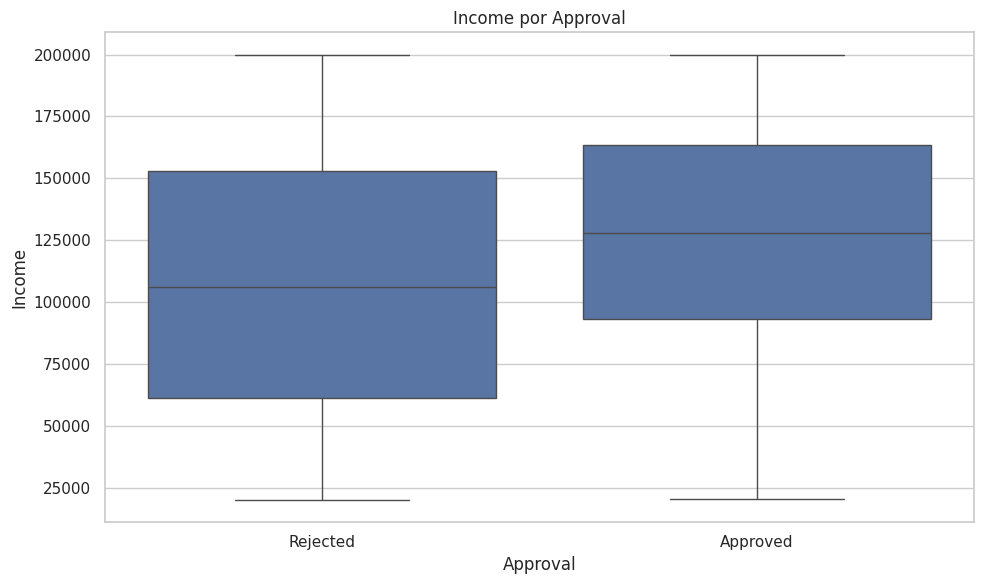

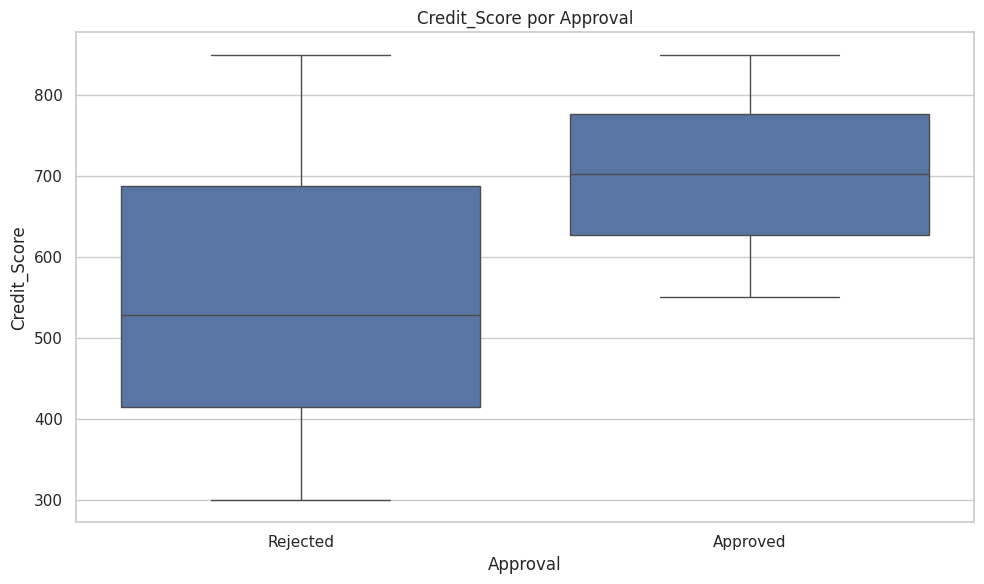

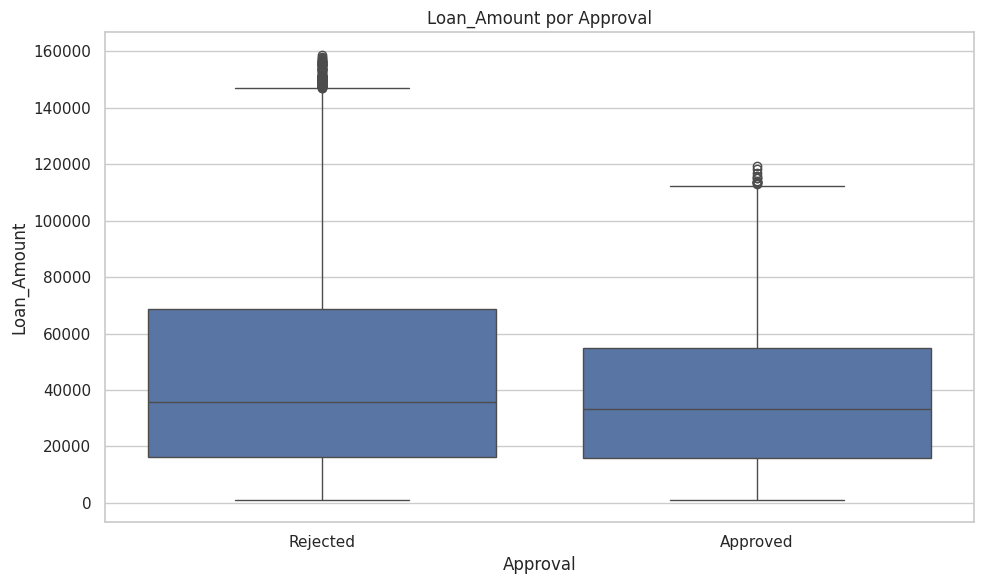

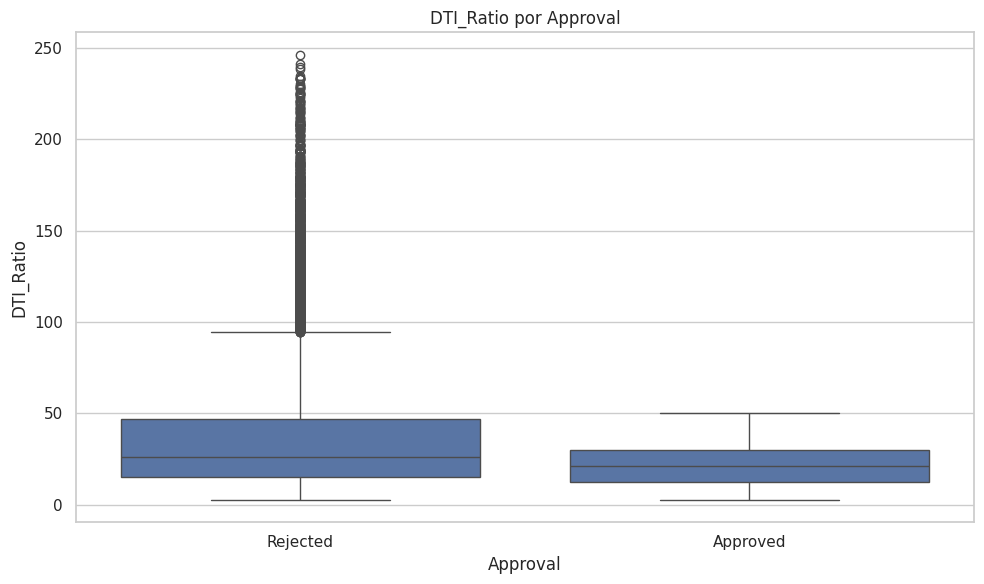

In [31]:
plot_boxplots(df, numeric_cols, 'Approval')

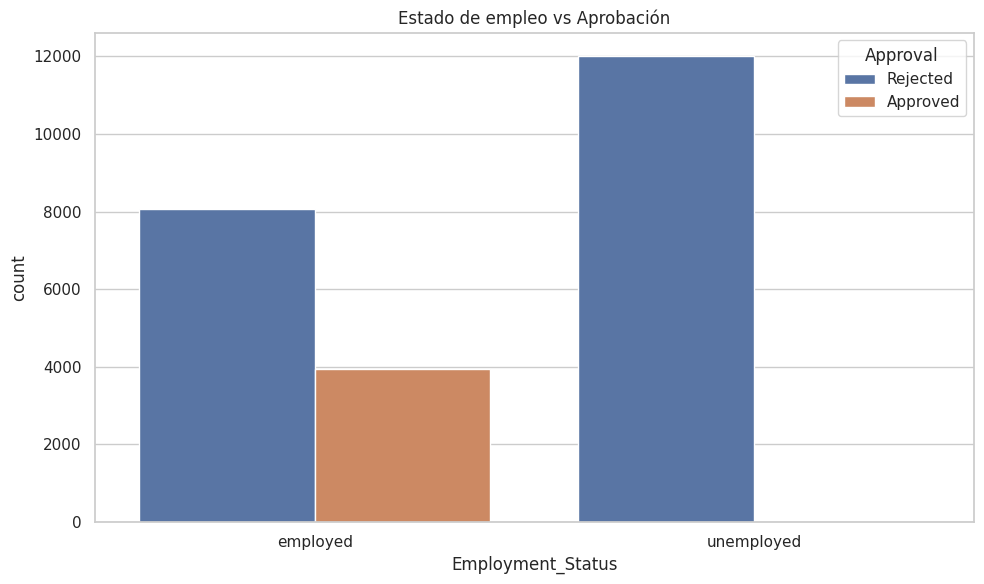

In [32]:
plot_employment_vs_approval(df)

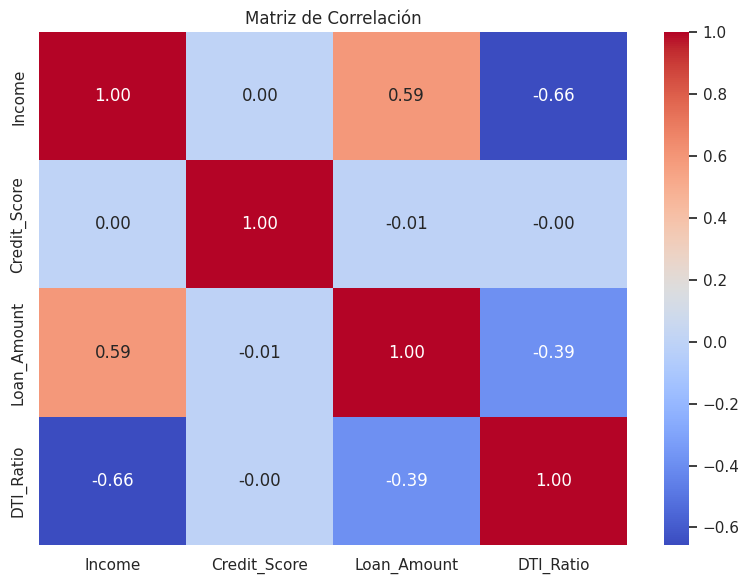

In [33]:
plot_correlation_heatmap(df)

In [34]:
# Mostrar estadísticas descriptivas completas
df.describe(include='all')

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
count,24000,24000.000000,24000.000000,24000.000000,24000.000000,24000,24000
unique,70,NaN,NaN,NaN,NaN,2,2
top,I need funds to upgrade my computer and buy so...,NaN,NaN,NaN,NaN,unemployed,Rejected
freq,385,NaN,NaN,NaN,NaN,12007,20067
mean,NaN,110377.552708,575.720333,44356.154833,34.719167,NaN,NaN
std,NaN,51729.677627,159.227621,34666.604785,32.322471,NaN,NaN
min,NaN,20001.000000,300.000000,1005.000000,2.530000,NaN,NaN
25%,NaN,65635.750000,437.000000,16212.000000,14.507500,NaN,NaN
50%,NaN,110464.000000,575.000000,35207.000000,24.860000,NaN,NaN
75%,NaN,155187.000000,715.000000,65622.750000,41.840000,NaN,NaN


In [35]:
# --------- PREPARACIÓN GENERAL ---------
df['Employment_Status'] = LabelEncoder().fit_transform(df['Employment_Status'])  # employed=0, unemployed=1
df['Approval'] = LabelEncoder().fit_transform(df['Approval'])  # Rejected=0, Approved=1

# ------------------- 1. REGRESIÓN LINEAL -------------------
features_reg = ['Income', 'Credit_Score', 'DTI_Ratio', 'Employment_Status']
Xr = df[features_reg]
yr = df['Loan_Amount']

scaler = StandardScaler()
Xr_scaled = scaler.fit_transform(Xr)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr_scaled, yr, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

print("---- REGRESIÓN LINEAL ----")
print(f"R²: {r2_score(yr_test, yr_pred):.4f}")
print(f"MAE: {mean_absolute_error(yr_test, yr_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(yr_test, yr_pred)):.2f}\n")


# ------------------- 2. REG. LOGÍSTICA + TEXTO -------------------
# Procesar texto
tfidf = TfidfVectorizer(max_features=100)
X_text = tfidf.fit_transform(df['Text']).toarray()

X_struct = df[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio', 'Employment_Status']]
X_struct_scaled = scaler.fit_transform(X_struct)

# Concatenar texto + numérico
from numpy import hstack
X_combined = hstack([X_struct_scaled, X_text])
y_cls = df['Approval']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_combined, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(Xc_train, yc_train)
yc_pred = log_reg.predict(Xc_test)

print("---- CLASIFICACIÓN (Regresión Logística + Texto) ----")
print(f"Accuracy: {accuracy_score(yc_test, yc_pred):.4f}")
print("Matriz de Confusión:")
print(confusion_matrix(yc_test, yc_pred))
print("Reporte de Clasificación:")
print(classification_report(yc_test, yc_pred))


# ------------------- 3. RANDOM FOREST -------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\n🌳 Evaluación Random Forest Classifier")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, rf_pred))
print("Reporte de Clasificación:")
print(classification_report(y_test, rf_pred, target_names=le_approval.classes_))

---- REGRESIÓN LINEAL ----
R²: 0.3365
MAE: 22041.97
RMSE: 28017.66

---- CLASIFICACIÓN (Regresión Logística + Texto) ----
Accuracy: 0.9356
Matriz de Confusión:
[[ 627  160]
 [ 149 3864]]
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       787
           1       0.96      0.96      0.96      4013

    accuracy                           0.94      4800
   macro avg       0.88      0.88      0.88      4800
weighted avg       0.94      0.94      0.94      4800


🌳 Evaluación Random Forest Classifier
Accuracy: 0.9958
Matriz de Confusión:
[[ 781    6]
 [  14 3999]]
Reporte de Clasificación:
              precision    recall  f1-score   support

    Approved       0.98      0.99      0.99       787
    Rejected       1.00      1.00      1.00      4013

    accuracy                           1.00      4800
   macro avg       0.99      0.99      0.99      4800
weighted avg       1.00      1.00      1.00      4800

